In [3]:
import math

import re

import os

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

from sklearn.feature_selection import f_classif

In [5]:
sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (8, 5)

plt.rcParams["axes.titleweight"] = "bold"

In [7]:
#load dataset

In [11]:
df = pd.read_csv("cardio_train.csv", sep=";")

print("Dataset Shape:", df.shape)

print("Columns:", list(df.columns))

Dataset Shape: (70000, 13)
Columns: ['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']


In [13]:
print("Dataset Information")
df.info()

print("\nStatistical Summary")
print(df.describe().T)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB

Statistical Summary
               count          mean           std      min       25%      50%  \
id           70000.0  49972.419900  28851.302323      0.0  25006.75  50001.5   
age      

In [15]:
#data quality check-missing values and duplicates

In [17]:
print("Duplicate Rows:", df.duplicated().sum())

missing_df = pd.DataFrame({

    "Missing Count": df.isna().sum(),

    "Missing %": round(df.isna().sum() / len(df) * 100, 2)

})

print("Missing Values")
print(" ")
print(missing_df)

Duplicate Rows: 0
Missing Values
 
             Missing Count  Missing %
id                       0        0.0
age                      0        0.0
gender                   0        0.0
height                   0        0.0
weight                   0        0.0
ap_hi                    0        0.0
ap_lo                    0        0.0
cholesterol              0        0.0
gluc                     0        0.0
smoke                    0        0.0
alco                     0        0.0
active                   0        0.0
cardio                   0        0.0


In [21]:
#target distribution=cardio or no cardio

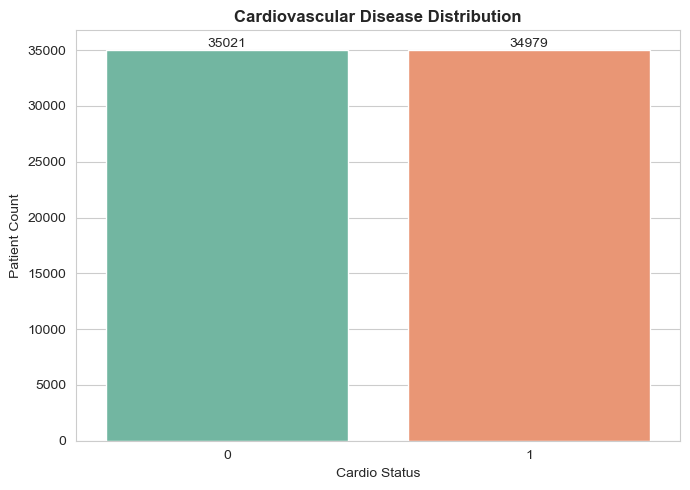

In [23]:
plt.figure(figsize=(7,5))

ax = sns.countplot(

    data=df,

    x='cardio',

    hue='cardio',

    palette='Set2',

    legend=False

)

plt.title("Cardiovascular Disease Distribution")

plt.xlabel("Cardio Status")

plt.ylabel("Patient Count")

for p in ax.patches:

    ax.annotate(

        f"{int(p.get_height())}",

        (p.get_x() + p.get_width()/2, p.get_height()),

        ha='center',

        va='bottom'

    )

plt.tight_layout()

plt.show()

In [25]:
#configure features and target

In [27]:
INPUT_FEATURES = [

    'id',

    'age',

    'gender',

    'height',

    'weight',

    'ap_hi',

    'ap_lo',

    'cholesterol',

    'gluc',

    'smoke',

    'alco',

    'active'

]

TARGET = 'cardio'

In [29]:
#remove id column

In [31]:
def drop_unnwanted_features(df, feature):

    if feature in df.columns:

        df = df.drop(columns=feature)

    if feature in INPUT_FEATURES:

        INPUT_FEATURES.remove(feature)

    return df

df = drop_unnwanted_features(df, 'id')

In [33]:
#outlier analysis before

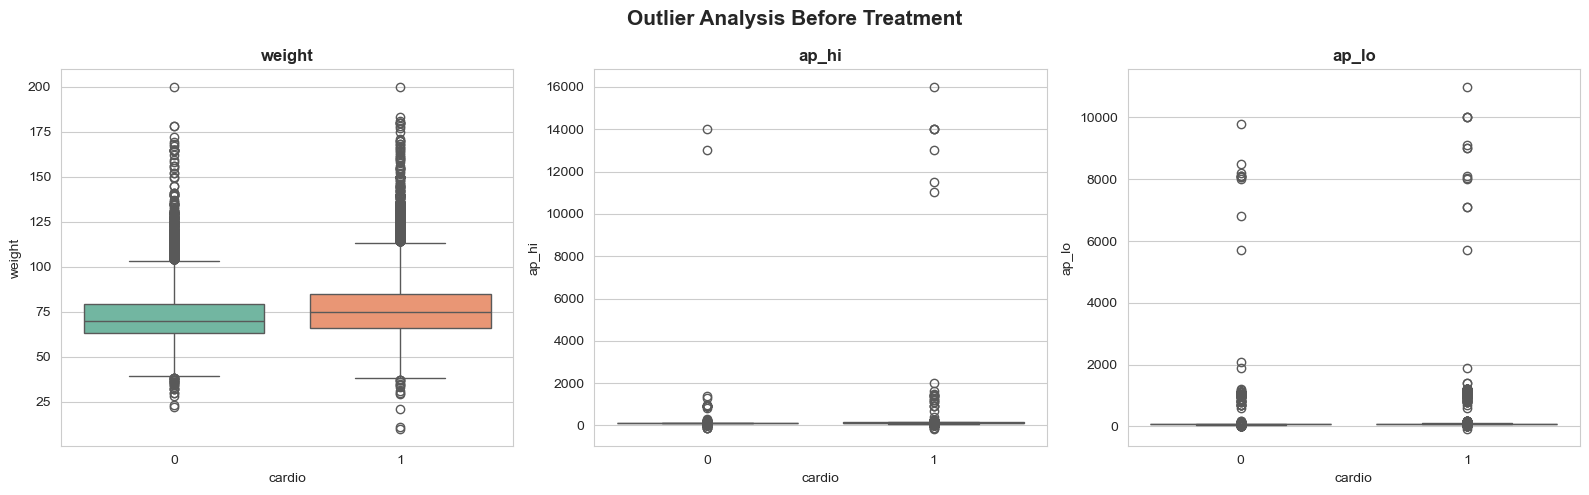

In [35]:
important_features = ['weight', 'ap_hi', 'ap_lo']

fig, axes = plt.subplots(1, 3, figsize=(16,5))

for ax, feature in zip(axes, important_features):

    sns.boxplot(

        data=df,

        x='cardio',

        y=feature,

        hue='cardio',

        palette='Set2',

        legend=False,

        ax=ax

    )

    ax.set_title(feature)

plt.suptitle(

    "Outlier Analysis Before Treatment",

    fontsize=15,

    fontweight='bold'

)

plt.tight_layout()

plt.show()

In [37]:
#outlier treatment using IQR

In [45]:
def IQR(series):

    Q1 = series.quantile(0.25)

    Q3 = series.quantile(0.75)

    iqr = Q3 - Q1

    lower = Q1 - 1.5 * iqr

    upper = Q3 + 1.5 * iqr

    return series.clip(lower=lower, upper=upper)

exclude = [

    'gluc',

    'alco',

    'smoke',

    'cholesterol',

    'active'

]
continuous_features = [
    'age',
    'height',
    'weight',
    'ap_hi',
    'ap_lo'
]

df[continuous_features] = df[continuous_features].astype(float)

for feature in [f for f in INPUT_FEATURES if f not in exclude]:

    for cls in df[TARGET].unique():

        mask = df[TARGET] == cls

        df.loc[mask, feature] = IQR(

            df.loc[mask, feature]

        )

In [47]:
#outlier analysis after

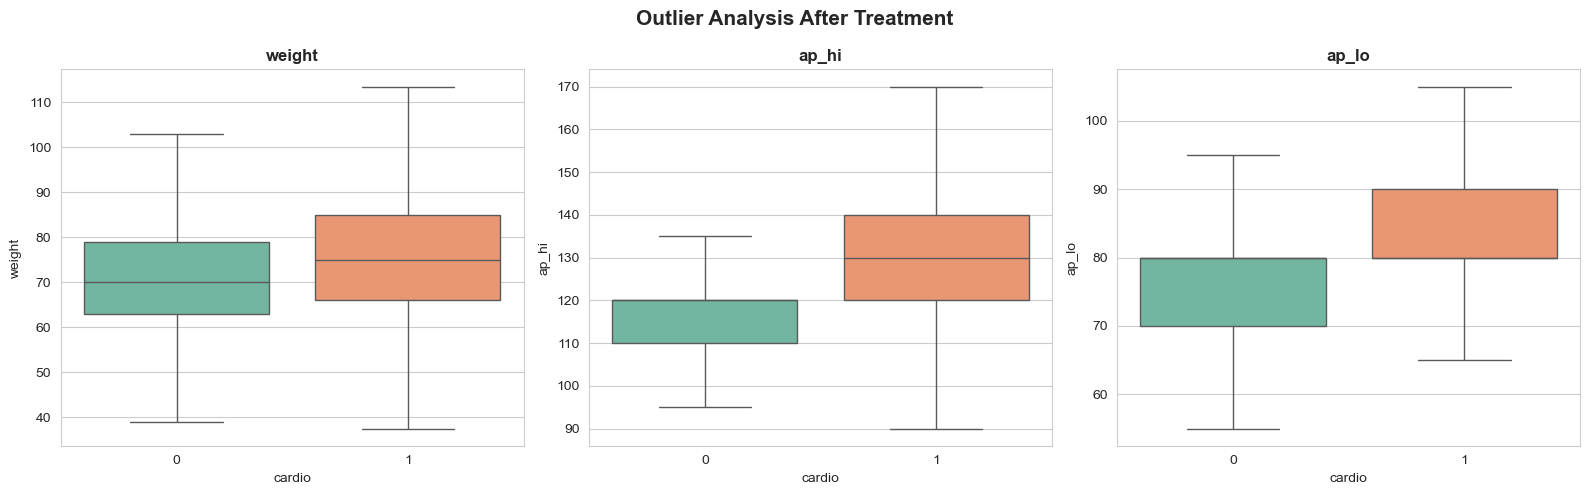

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))

for ax, feature in zip(axes, important_features):

    sns.boxplot(

        data=df,

        x='cardio',

        y=feature,

        hue='cardio',

        palette='Set2',

        legend=False,

        ax=ax

    )

    ax.set_title(feature)

plt.suptitle(

    "Outlier Analysis After Treatment",

    fontsize=15,

    fontweight='bold'

)

plt.tight_layout()

plt.show()

In [51]:
#feature engineering

In [53]:
df['age_years'] = (

    df['age'] / 365

).round().astype(int)

df['height'] = df['height'] / 100

df['bmi'] = (

    df['weight'] /

    (df['height'] ** 2)

)

df['pulse_pressure'] = (

    df['ap_hi'] -

    df['ap_lo']

)

df['health_index'] = (

    (df['active'] * 1)

    - (df['smoke'] * 0.5)

    - (df['alco'] * 0.5)

)

df['cholesterol_gluc_interaction'] = (

    df['cholesterol'] *

    df['gluc']

)

In [55]:
#update feature list

In [57]:
new_features = [

    'age_years',

    'bmi',

    'pulse_pressure',

    'health_index',

    'cholesterol_gluc_interaction'

]

INPUT_FEATURES += [

    f for f in new_features

    if f not in INPUT_FEATURES

]

In [59]:
#remove redundant features-age,height

In [61]:
df = drop_unnwanted_features(df, 'age')

df = drop_unnwanted_features(df, 'height')

In [63]:
#engineered feature distribution

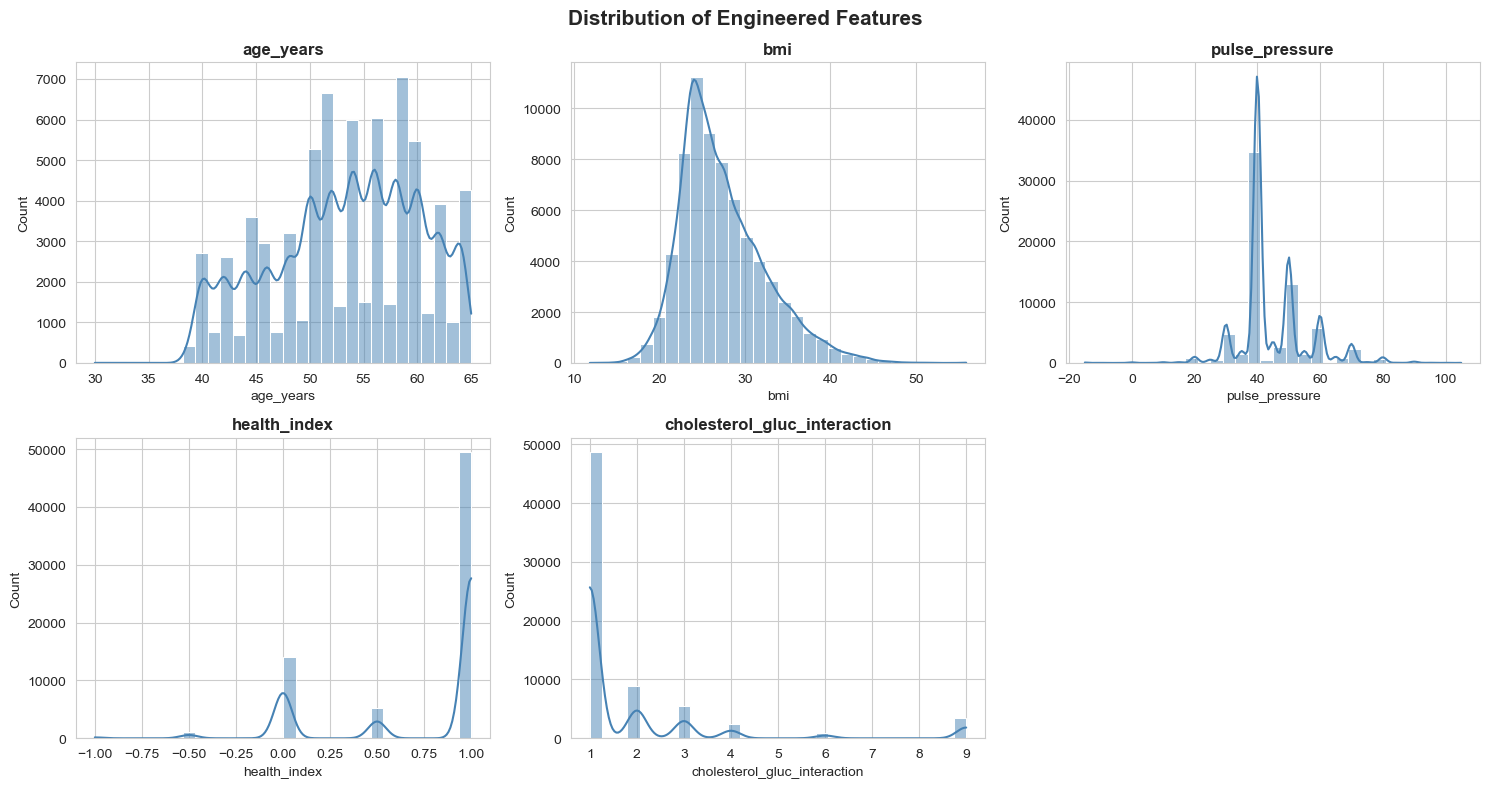

In [65]:
fig, axes = plt.subplots(

    2,

    3,

    figsize=(15,8)

)

axes = axes.flatten()

for i, feature in enumerate(new_features):

    sns.histplot(

        df[feature],

        kde=True,

        bins=30,

        color='steelblue',

        ax=axes[i]

    )

    axes[i].set_title(feature)

axes[-1].axis('off')

plt.suptitle(

    "Distribution of Engineered Features",

    fontsize=15,

    fontweight='bold'

)

plt.tight_layout()

plt.show()

In [67]:
#bmi vs cvd risk

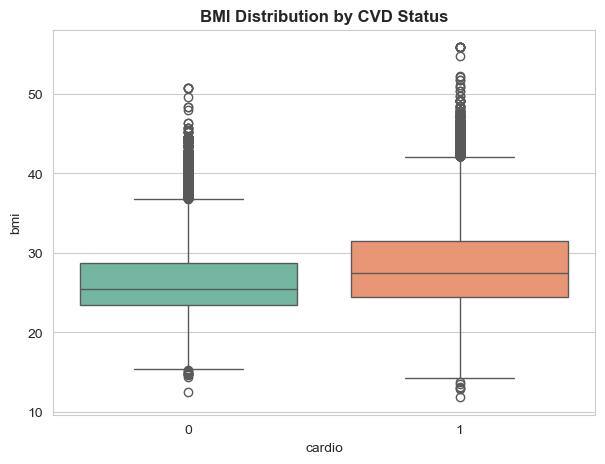

In [69]:
plt.figure(figsize=(7,5))

sns.boxplot(

    data=df,

    x='cardio',

    y='bmi',

    hue='cardio',

    palette='Set2',

    legend=False

)

plt.title("BMI Distribution by CVD Status")

plt.show()

In [71]:
#pulse pressure vs cvd

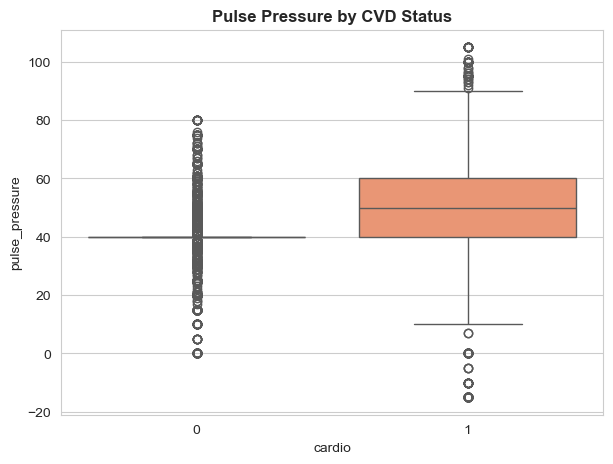

In [73]:
plt.figure(figsize=(7,5))

sns.boxplot(

    data=df,

    x='cardio',

    y='pulse_pressure',

    hue='cardio',

    palette='Set2',

    legend=False

)

plt.title("Pulse Pressure by CVD Status")

plt.show()

In [75]:
#correct pulse pressure values 

In [77]:
flipped_mask = df['ap_lo'] > df['ap_hi']
df.loc[flipped_mask, ['ap_hi', 'ap_lo']] = df.loc[flipped_mask, ['ap_lo', 'ap_hi']].values

df = df[
    (df['ap_hi'] >= 80) & (df['ap_hi'] <= 220) &
    (df['ap_lo'] >= 40) & (df['ap_lo'] <= 130)
]


df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']


print(f"Remaining dataset shape: {df.shape}")
print("\nPulse Pressure Summary:")
print(df['pulse_pressure'].describe())

Remaining dataset shape: (70000, 15)

Pulse Pressure Summary:
count    70000.000000
mean        44.730729
std         10.851169
min          0.000000
25%         40.000000
50%         40.000000
75%         50.000000
max        105.000000
Name: pulse_pressure, dtype: float64


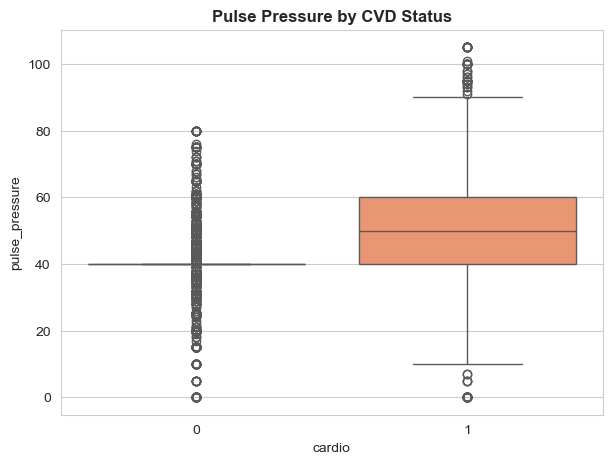

In [79]:
plt.figure(figsize=(7,5))

sns.boxplot(

    data=df,

    x='cardio',

    y='pulse_pressure',

    hue='cardio',

    palette='Set2',

    legend=False

)

plt.title("Pulse Pressure by CVD Status")

plt.show()

In [85]:
#detect redundant features by correlation and remove them 

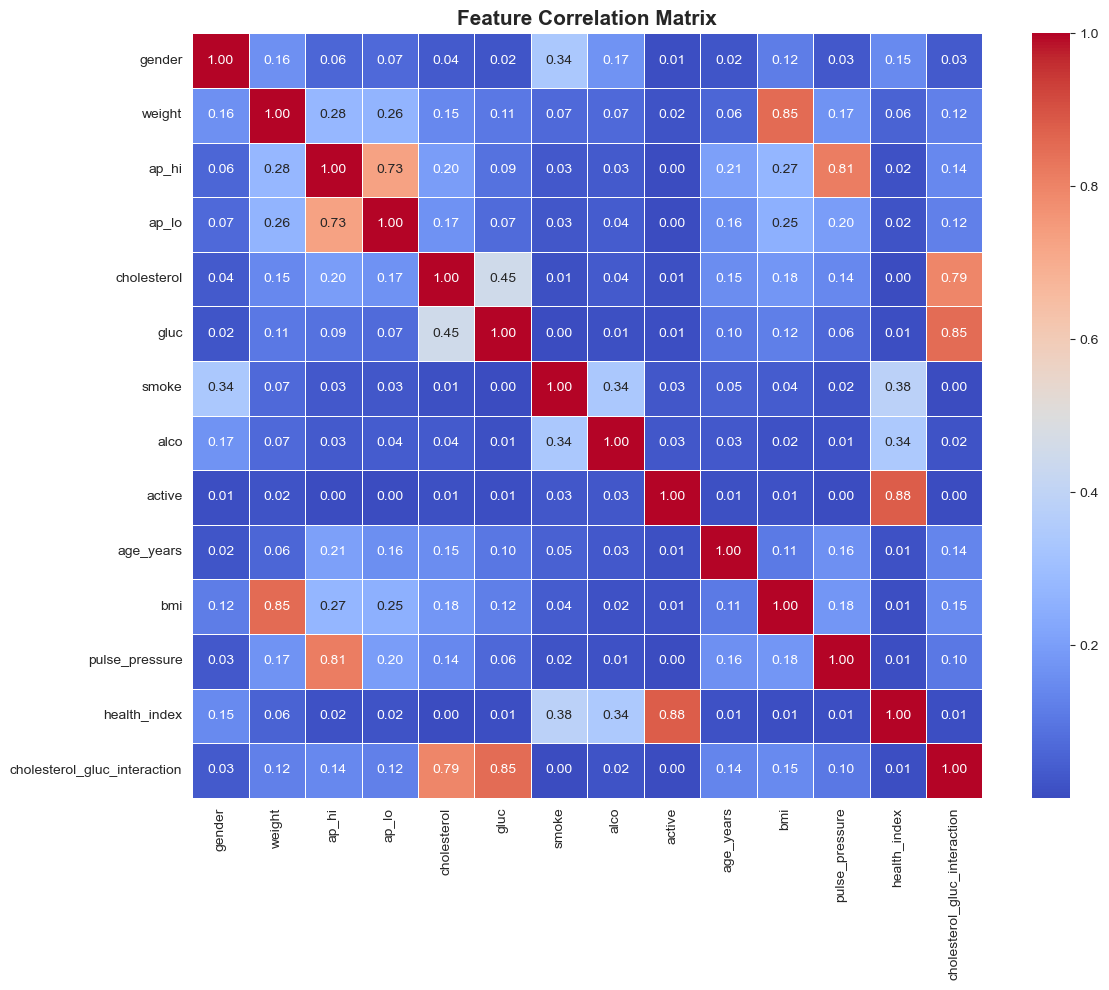

In [87]:
corr_matrix = df[INPUT_FEATURES].corr().abs()

plt.figure(figsize=(12, 10))

sns.heatmap(

    corr_matrix,

    cmap='coolwarm',

    annot=True,

    fmt='.2f',

    linewidths=0.5

)

plt.title(

    "Feature Correlation Matrix",

    fontsize=15,

    fontweight='bold'

)

plt.tight_layout()

plt.show()

In [89]:
#find highly correlated features

In [91]:
CORRELATION_THRESHOLD = 0.85

corr_matrix = df[INPUT_FEATURES].corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

high_corr_pairs = []

for col in upper_triangle.columns:

    for row in upper_triangle.index:

        corr_value = upper_triangle.loc[row, col]

        if pd.notna(corr_value) and corr_value > CORRELATION_THRESHOLD:

            high_corr_pairs.append(
                [row, col, round(corr_value, 3)]
            )

high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=[
        'Feature_1',
        'Feature_2',
        'Correlation'
    ]
)

print("\nHighly Correlated Feature Pairs")
print(" ")

if len(high_corr_df) > 0:
    print(
        high_corr_df.sort_values(
            by='Correlation',
            ascending=False
        )
    )
else:
    print("No highly correlated features found.")


Highly Correlated Feature Pairs
 
  Feature_1     Feature_2  Correlation
1    active  health_index        0.882
0    weight           bmi        0.855


In [97]:
if 'health_index' in INPUT_FEATURES:
    INPUT_FEATURES.remove('health_index')

df.drop(columns='health_index', inplace=True)

In [99]:
if 'weight' in INPUT_FEATURES:
    INPUT_FEATURES.remove('weight')

df.drop(columns='weight', inplace=True)

In [101]:
#feature selection using ANOVA

In [103]:
f_values, p_values = f_classif(

    df[INPUT_FEATURES],

    df[TARGET]

)

anova_df = pd.DataFrame({

    'Feature': INPUT_FEATURES,

    'F_Value': f_values,

    'P_Value': p_values

})

anova_df = anova_df.sort_values(

    'F_Value',

    ascending=True

)

print("\nANOVA Results")

print(" ")

print(anova_df)


ANOVA Results
 
                         Feature       F_Value        P_Value
6                           alco      3.761355   5.245406e-02
0                         gender      4.603641   3.190755e-02
5                          smoke     16.790541   4.178780e-05
7                         active     89.091494   3.880438e-21
4                           gluc    562.772977  6.483043e-124
11  cholesterol_gluc_interaction   1786.315150   0.000000e+00
9                            bmi   3015.623374   0.000000e+00
3                    cholesterol   3599.361137   0.000000e+00
8                      age_years   4193.661786   0.000000e+00
2                          ap_lo  11539.397799   0.000000e+00
10                pulse_pressure  12070.707734   0.000000e+00
1                          ap_hi  22118.540476   0.000000e+00


In [105]:
#anova feature importance

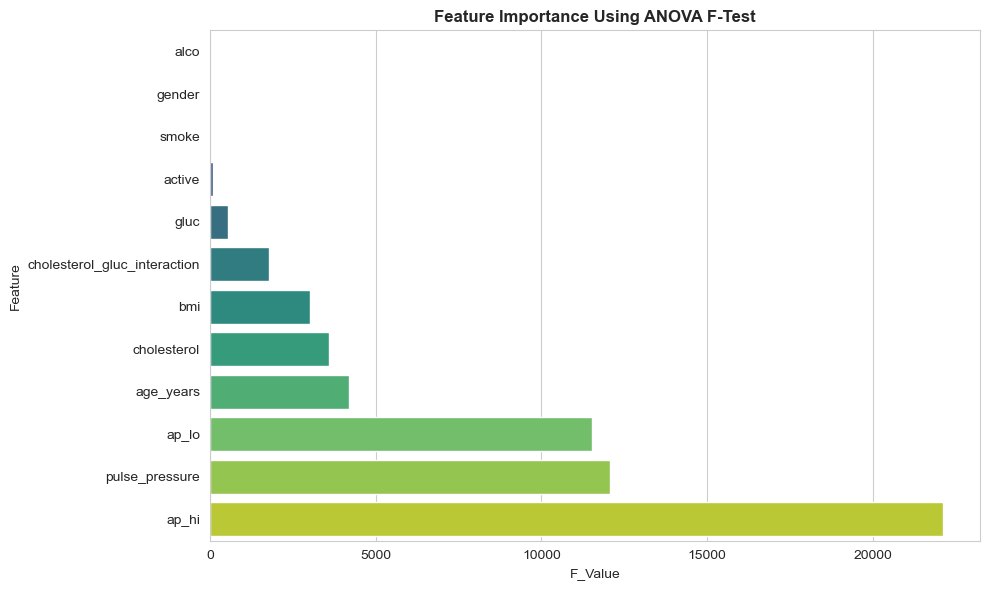

In [107]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=anova_df,

    x='F_Value',

    y='Feature',

    hue='Feature',

    palette='viridis',

    legend=False

)

plt.title(

    "Feature Importance Using ANOVA F-Test"

)

plt.tight_layout()

plt.show()

In [109]:
#scaling

In [113]:
from sklearn.preprocessing import MinMaxScaler

continuous_features = [

    'ap_hi',

    'ap_lo',

    'age_years',

    'bmi',

    'pulse_pressure',

    'cholesterol_gluc_interaction'

]

scaler = MinMaxScaler()

df[continuous_features] = scaler.fit_transform(

    df[continuous_features]

)

print("Scaling completed successfully.")

Scaling completed successfully.


In [115]:
#verify the scaling

In [117]:
scaling_verification = (

    df[continuous_features]

    .agg(['min', 'max'])

    .T

)

print("\nScaling Verification")

print("  ")

print(scaling_verification)


Scaling Verification
  
                              min  max
ap_hi                         0.0  1.0
ap_lo                         0.0  1.0
age_years                     0.0  1.0
bmi                           0.0  1.0
pulse_pressure                0.0  1.0
cholesterol_gluc_interaction  0.0  1.0


In [119]:
#summary of final dataset

In [121]:
print("Final Dataset Shape")

print(df.shape)

print("\nFinal Features")

print(" ")

for feature in INPUT_FEATURES:

    print(feature)

Final Dataset Shape
(70000, 13)

Final Features
 
gender
ap_hi
ap_lo
cholesterol
gluc
smoke
alco
active
age_years
bmi
pulse_pressure
cholesterol_gluc_interaction


In [123]:
#save the preprocessed dataset

In [125]:
OUTPUT_FILE = "cardio_train_preprocessed.csv"

df.to_csv(

    OUTPUT_FILE,

    index=False

)

print(f"\nPreprocessed dataset saved as: {OUTPUT_FILE}")


Preprocessed dataset saved as: cardio_train_preprocessed.csv
